In [1]:
import pandas as pd
from rdkit.Chem.Scaffolds import MurckoScaffold

from sample_dataset import sample_dataset

In [2]:
docking_df = pd.read_csv("../docking/results.csv", names=["zincid", "smiles", "docking_score"])
docking_df = docking_df.set_index("zincid")
mmpbsa_df = pd.read_csv("../mmpbsa_dg_en_gb_avg.csv")
mmpbsa_df = mmpbsa_df.set_index("name")
df = mmpbsa_df.join(docking_df, how="inner", lsuffix="_mmpbsa", rsuffix="_docking")
assert (df["smiles_mmpbsa"] == df["smiles_docking"]).all()
df["smiles"] = df["smiles_mmpbsa"]
df = df.drop(["smiles_mmpbsa", "smiles_docking"], axis="columns")
df["scaffolds"] = df["smiles"].map(MurckoScaffold.MurckoScaffoldSmiles)
df.describe()

,target,docking_score
count,60059.000000,60059.000000
mean,-31.476314,-8.335278
std,5.507552,0.927935
min,-54.684265,-11.909000
25%,-35.151225,-9.087000
50%,-31.556451,-8.245000
75%,-27.877224,-7.614000
max,-9.219612,-5.637000


In [3]:
import numpy as np
from sklearn.linear_model import RidgeCV

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

In [4]:
mpfgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

In [5]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


class MLPRegressor(nn.Module):
    def __init__(self, input_size, hidden_layer_sizes=(1024, 1024, 512, 256)):
        super(MLPRegressor, self).__init__()
        self.hidden_layer_sizes = hidden_layer_sizes
        layers = []

        # Input layer
        layers.append(nn.Linear(input_size, hidden_layer_sizes[0]))
        layers.append(nn.ReLU())

        # Hidden layers
        for i in range(len(hidden_layer_sizes) - 1):
            layers.append(nn.Linear(hidden_layer_sizes[i], hidden_layer_sizes[i + 1]))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(hidden_layer_sizes[-1], 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x).squeeze()


    def fit(self, X: np.ndarray, y: np.ndarray, epochs: int = 50, device="cuda"):
        optimizer = optim.AdamW(
            self.parameters(),
            lr=0.001,
            betas=(0.9, 0.999),
            eps=1e-8,
            weight_decay=0.01,
        )

        loss_fn = nn.HuberLoss()

        X, y = torch.from_numpy(X).float(), torch.from_numpy(y).float()

        train_dataset = TensorDataset(X, y)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


        _train_curve = []
        for epoch in range(epochs):
            # Training phase
            self.train()
            train_loss = 0.0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                outputs = self(batch_X)
                loss = loss_fn(outputs, batch_y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            avg_train_loss = train_loss / len(train_loader)
            _train_curve.append(avg_train_loss)

        plt.plot(_train_curve)
    
    @torch.no_grad()
    def predict(self, X: np.ndarray):
        X = torch.from_numpy(X).float()
        loader = DataLoader(X, batch_size=256, shuffle=False)

        predictions = []
        self.eval()
        for batch_X in loader:
            predictions.append(self(batch_X.to("cuda")).cpu())

        return torch.cat(predictions).numpy()

/home/max/mambaforge/envs/protein_ligand/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from sklearn.utils import gen_batches


def featurize(smiles: list[str], kind):
    molecules = list(map(Chem.MolFromSmiles, smiles))
    if kind == "fingerprint":
        return np.vstack(list(map(mpfgen.GetFingerprintAsNumPy, molecules)))
    else:
        from transformers import AutoModel, AutoTokenizer
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        if kind == "chemberta":
            model = AutoModel.from_pretrained("DeepChem/ChemBERTa-77M-MTR").to(device)
            tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MTR")
        elif kind == "molformer":
            model = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True).to(device)
            tokenizer = AutoTokenizer.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

        pad_to = max(map(len, smiles))

        embeddings = []
        model.eval()
        for batch_idx in gen_batches(len(smiles), 256):
            model_inputs = tokenizer(
                smiles[batch_idx],
                padding="max_length",
                max_length=pad_to,
                return_tensors="pt"
            ).to(device)
            with torch.no_grad():
                output = model(**model_inputs)
                
                if kind == "chemberta":
                    embeddings.append(output.last_hidden_state[:, 0, :].cpu())
                else:
                    embeddings.append(output.pooler_output.cpu())
                
        return torch.cat(embeddings, dim=0).numpy()
    

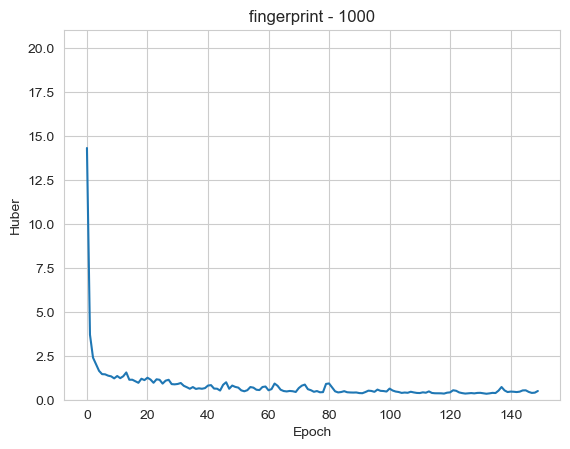

KeyError: 'Enrichment factor'

In [7]:
results = []

nice_feature_names = {"chemberta": "ChemBERTa-2", "molformer": "MolFormer", "fingerprint": "Morgan Fingerprint"}

for size, epochs in [(1000, 150), (5000, 150), (10_000, 200)]:
    subset = sample_dataset(df["smiles"].to_list(), size, scaffolds=df["scaffolds"])    
    for feature_type in ["fingerprint", "chemberta", "molformer"]:    
        X = featurize(df["smiles"].to_list(), feature_type)
        y = df["target"].values
    
        train_idx = df["smiles"].isin(subset["molecules"])
    
        train_X = X[train_idx]
        test_X = X[~train_idx]
    
        train_y = y[train_idx]
        test_y = y[~train_idx]
    
        model = MLPRegressor(X.shape[1], [1024, 1024, 512, 256])
        model = model.to("cuda")
        model.fit(train_X, train_y, epochs=epochs)
        
        plt.xlabel("Epoch")
        plt.ylabel("Huber")
        plt.title(f"{feature_type} - {size}")
        plt.ylim(0, 21)
        plt.show()


        predictions = model.predict(X)
    
        for q in [0.01, 0.05, 0.1]:
            quantile = df["target"].quantile(q)
            hits_true = df["target"] < quantile
            hits_pred = predictions < quantile
            
            overlap = (hits_true & hits_pred).sum()
            overlap_ratio = overlap / size
            pool_ratio = hits_true.sum() / len(df)
            
            data_ratio = len(df) / size
            recall = overlap / hits_true.sum()

            q_results = {
                "Training samples": size,
                "Quantile Size": hits_true.sum(),
                "Quantile": q,
                "Recall": recall,
                "Enrichment Factor": recall * data_ratio,
                "overlap_ratio": overlap_ratio,
                "pool_ratio": pool_ratio,
                "max_enrichment_factor": data_ratio,
                "Feature": nice_feature_names[feature_type],
                "Overlap": overlap,
                "Ratio_D": data_ratio,
                "Ratio_R": overlap / hits_true.sum()
            }
    
            results.append(q_results)

results = pd.DataFrame(results)
results

In [65]:
results["Feature"] = results["Feature"].map()
results = results.rename({"Enrichment factor": "Enrichment Factor"})
results

,Training samples,Quantile Size,Quantile,Recall,Enrichment factor,overlap_ratio,pool_ratio,max_enrichment_factor,Feature,Overlap,Ratio_D,Ratio_R
0,1000,601,0.01,0.048,2.898,0.029,0.01,60.059,NaN,29,60.059,0.048
1,1000,3003,0.05,0.186,11.200,0.560,0.05,60.059,NaN,560,60.059,0.186
2,1000,6006,0.10,0.213,12.790,1.279,0.10,60.059,NaN,1279,60.059,0.213
3,1000,601,0.01,0.050,2.998,0.030,0.01,60.059,NaN,30,60.059,0.050
4,1000,3003,0.05,0.203,12.200,0.610,0.05,60.059,NaN,610,60.059,0.203
5,1000,6006,0.10,0.289,17.350,1.735,0.10,60.059,NaN,1735,60.059,0.289
6,1000,601,0.01,0.002,0.100,0.001,0.01,60.059,NaN,1,60.059,0.002
7,1000,3003,0.05,0.036,2.160,0.108,0.05,60.059,NaN,108,60.059,0.036
8,1000,6006,0.10,0.074,4.440,0.444,0.10,60.059,NaN,444,60.059,0.074
9,5000,601,0.01,0.120,1.439,0.014,0.01,12.012,NaN,72,12.012,0.120


In [66]:
results[["Quantile", "max_enrichment_factor"]].drop_duplicates()

,Quantile,max_enrichment_factor
0,0.01,60.059
1,0.05,60.059
2,0.10,60.059
9,0.01,12.012
10,0.05,12.012
11,0.10,12.012
18,0.01,6.006
19,0.05,6.006
20,0.10,6.006


In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
# sns.set_context("talk")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    'font.size': 16, 
    "lines.linewidth": 2, 
    "axes.labelsize": 18,
    "axes.titlesize": 22
})

In [68]:
g = sns.relplot(
    results, 
    x="Training samples", y="Recall", 
    hue="Quantile",
    col="Feature",
    kind="line",
    palette="crest",
    marker="o",
    legend=False
)

g.set_titles(col_template="{col_name}")

from matplotlib import colormaps
from matplotlib.lines import Line2D

cm = colormaps["crest"]
colors = cm(plt.Normalize()([0.01, 0.05, 0.1]))


legend_elements = [
    Line2D([0], [0], color='white', label='Quantile:', visible=False),
    Line2D([0], [0], color=colors[0], label='0.01'),
    Line2D([0], [0], color=colors[1], label='0.05'),
    Line2D([0], [0], color=colors[2], label='0.1'),
]

# Get the figure object
fig = plt.gcf()

# Add the combined legend to the figure
legend = fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
                    ncol=4, columnspacing=1, handletextpad=0.5)

# Adjust the appearance of the legend
for text in legend.get_texts():
    if text.get_text() in ['Quantile:']:
        text.set_ha('left')  # Align category labels to the left
        text.set_position((-20, 0))  # Adjust the position as needed

# Adjust the subplot layout to make room for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

g.map(lambda color: plt.gca().set_xticks([1000, 5000, 10_000]))
g.savefig("../baseline_recall.pdf", format="pdf", dpi=300)

KeyError: 'Feature'

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


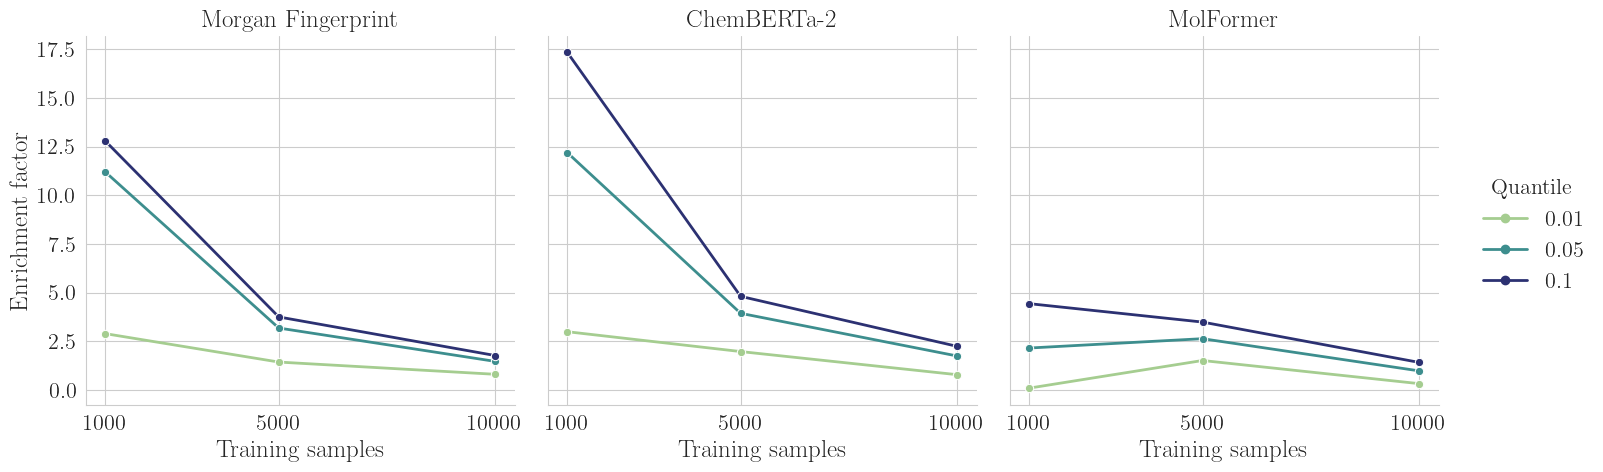

In [63]:
g = sns.relplot(
    results, 
    x="Training samples", y="Enrichment factor", 
    hue="Quantile",
    col="Feature",
    kind="line",
    palette="crest",
    marker="o"
)

g.set_titles(col_template="{col_name}")

g.map(lambda color: plt.gca().set_xticks([1000, 5000, 10_000]))
g.savefig("../baseline_ef.pdf", format="pdf", dpi=300)

In [64]:
X = results[results["Training samples"].isin([1000, 5000, 10_000])].sort_values(
    by=["Feature", "Quantile"]
)[["Feature", "Training samples", "Quantile", "Recall", "Enrichment factor"]]




X["Quantile"].unique()
pd.set_option("display.precision", 3)
X.to_csv("../baseline.csv", index=False)